# SEVA testing

#### 1. Get data from dataloader.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from seva.data.mvh_dataloader import MVHumanNetDataset
from torch.utils.data import DataLoader

# load dataset + dataloader
def expand_only_include(only_include):
    if isinstance(only_include, str): # in the format ex: "100001-102000,102020-104000"
        only_include = only_include.split(",")
        expanded_includes = []
        for subrange in only_include:
            start, end = [int(num) for num in subrange.split("-")]
            print(start, end)
            expanded_includes.extend([str(i).zfill(6) for i in range(start, end + 1)])
        return expanded_includes
    else:
        return only_include

dataset = MVHumanNetDataset(
    root_dir="/workspace/datasetvol/mvhuman_data/mv_captures",
    num_images=8,
    step_size=60,
    only_include=expand_only_include("104500-104700"),
    preload_path="/workspace/datasetvol/mvhuman_data/preload_paths/shards",
    iclight_dataset_path="/workspace/datasetvol/mvhuman_data/relit_images",
    # infu_dataset_path="/workspace/datasetvol/mvhuman_data/inconsistent_images",
    arcface_embeddings_dir="/workspace/datasetvol/mvhuman_data/arcface_embeddings",
    use_sapiens_conditioning=["depth", "seg_masks"],
    random_crop=False,
    maximal_crop=True,
    crop_padding=60,
    use_inconsistent=True,
    random_crop_prob=1.0,
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

104500 104700
Detected Arrow dataset at /workspace/datasetvol/mvhuman_data/preload_paths/shards
Loading Arrow dataset...
Loaded Arrow dataset with 5080 subjects


Indexing Arrow dataset: 100%|██████████| 5080/5080 [00:01<00:00, 3977.00it/s]


Loaded 561 scenes from Arrow dataset
MVHN::init done!


In [3]:
import torch

# check that dataloader works
batch_iterator = iter(loader)
batch = next(batch_iterator)
with torch.no_grad():
    print(batch["arcface_embedding"].sum(dim=0).sum(dim=1))

Error loading sapiens conditioning: 'CC32871A020_2105 is not a file in the archive'
Error loading sapiens conditioning: 'CC32871A020_2105 is not a file in the archive'
tensor([0., 0., 0., 0., 0., 0., 0., 0.])


### 2. Load model and get logged config & checkpoint.

In [11]:
# INPUT: logdir that contains the model checkpoint + config
from omegaconf import OmegaConf
from sgm.util import instantiate_from_config
import os

# required inputs
log_path = "/workspace/stonevol2/logs/arcface-attn/main_run1"
# log_path = "/workspace/stonevol/logs/2025-08-27T12-30-30_example_training-seva-phase1"
checkpoint_name = "epoch=000164.ckpt"
# checkpoint_name = "last.ckpt"

# get config
filename_base = os.path.basename(log_path).split("_")[0]
filename_base = "2025-11-22T08-46-52" # override to a specific timestamp
run_config = OmegaConf.load(f"{log_path}/configs/{filename_base}-project.yaml")
ckpt_path = f"{log_path}/checkpoints/{checkpoint_name}"

model_config = run_config.model
# parameters to change (from config)
model_config.params.sampler_config.params.guider_config.params.cfg_min = 1.0

# pretty print for debugging
# import pprint
# pprint.pprint(OmegaConf.to_container(model_config))

In [12]:

from sgm.models.diffusion import DiffusionEngine

engine = instantiate_from_config(run_config.model)
engine.init_from_ckpt(ckpt_path)
engine.eval()

SevaLoRAWrapper: Froze all parameters in Seva model.
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face.to_q
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face.to_k
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face.to_v
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face.to_out
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face.to_out.0
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.1.1.transformer_blocks.0.attn_face.to_out.1
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.2.1.transformer_blocks.0.attn_face
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.2.1.transformer_blocks.0.attn_face.to_q
[SevaLoRAWrapper] Unfroze all parameters for input_blocks.2.1.tra

DiffusionEngine(
  (model): SevaWrapper(
    (diffusion_model): SevaLoRAWrapper(
      (seva_model): Seva(
        (time_embed): Sequential(
          (0): Linear(in_features=320, out_features=1280, bias=True)
          (1): SiLU()
          (2): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (input_blocks): ModuleList(
          (0): TimestepEmbedSequential(
            (0): Conv2d(16, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (1-2): 2 x TimestepEmbedSequential(
            (0): ResBlock(
              (in_layers): Sequential(
                (0): GroupNorm32(32, 320, eps=1e-05, affine=True)
                (1): SiLU()
                (2): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
              (emb_layers): Sequential(
                (0): SiLU()
                (1): Linear(in_features=1280, out_features=320, bias=True)
              )
              (dense_emb_layers): Sequential(


### 3. Run inference using our proposed model
Note that we are still able to change the CFG after instantiating the model.

In [13]:
for param in engine.parameters(): # freeze all, inference mode
    param.requires_grad = False

In [14]:
import torch 
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch

def all_items_to_gpu(batch):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to("cuda")
    return batch

def cfg_test(batch, engine, scales=[0.0, 0.5, 1.0, 1.2, 2.0, 3.0, 5.0, 8.0]):
    for scale in scales:
        batch_copy = batch.copy()
        samples = run_step(batch_copy, engine, scale=scale)
        decoded_samples = normalize_tensor(engine.decode_first_stage(samples)).to("cpu")
        print(f"scale: {scale}")
        _ = show_tensor_batch(decoded_samples, masks=(batch_copy["ref_mask"].to("cpu")).squeeze(0))

def run_step(batch, engine, scale=1.0):
    batch = all_items_to_gpu(batch)
    engine = engine.to("cuda")
    with torch.autocast("cuda"):
        samples = engine.infer(batch, scale=scale).squeeze(0)
    return samples

batch = next(batch_iterator)
samples = run_step(batch, engine, scale=1.0)
# cfg_test(batch_, engine, scales=[0.0, 0.5, 1.0, 1.2, 2.0, 3.0, 5.0, 8.0])

mask: tensor([[ True,  True,  True,  True, False,  True,  True,  True]],
       device='cuda:0')
ref_mask: tensor([[ True, False, False, False, False, False, False, False]],
       device='cuda:0')


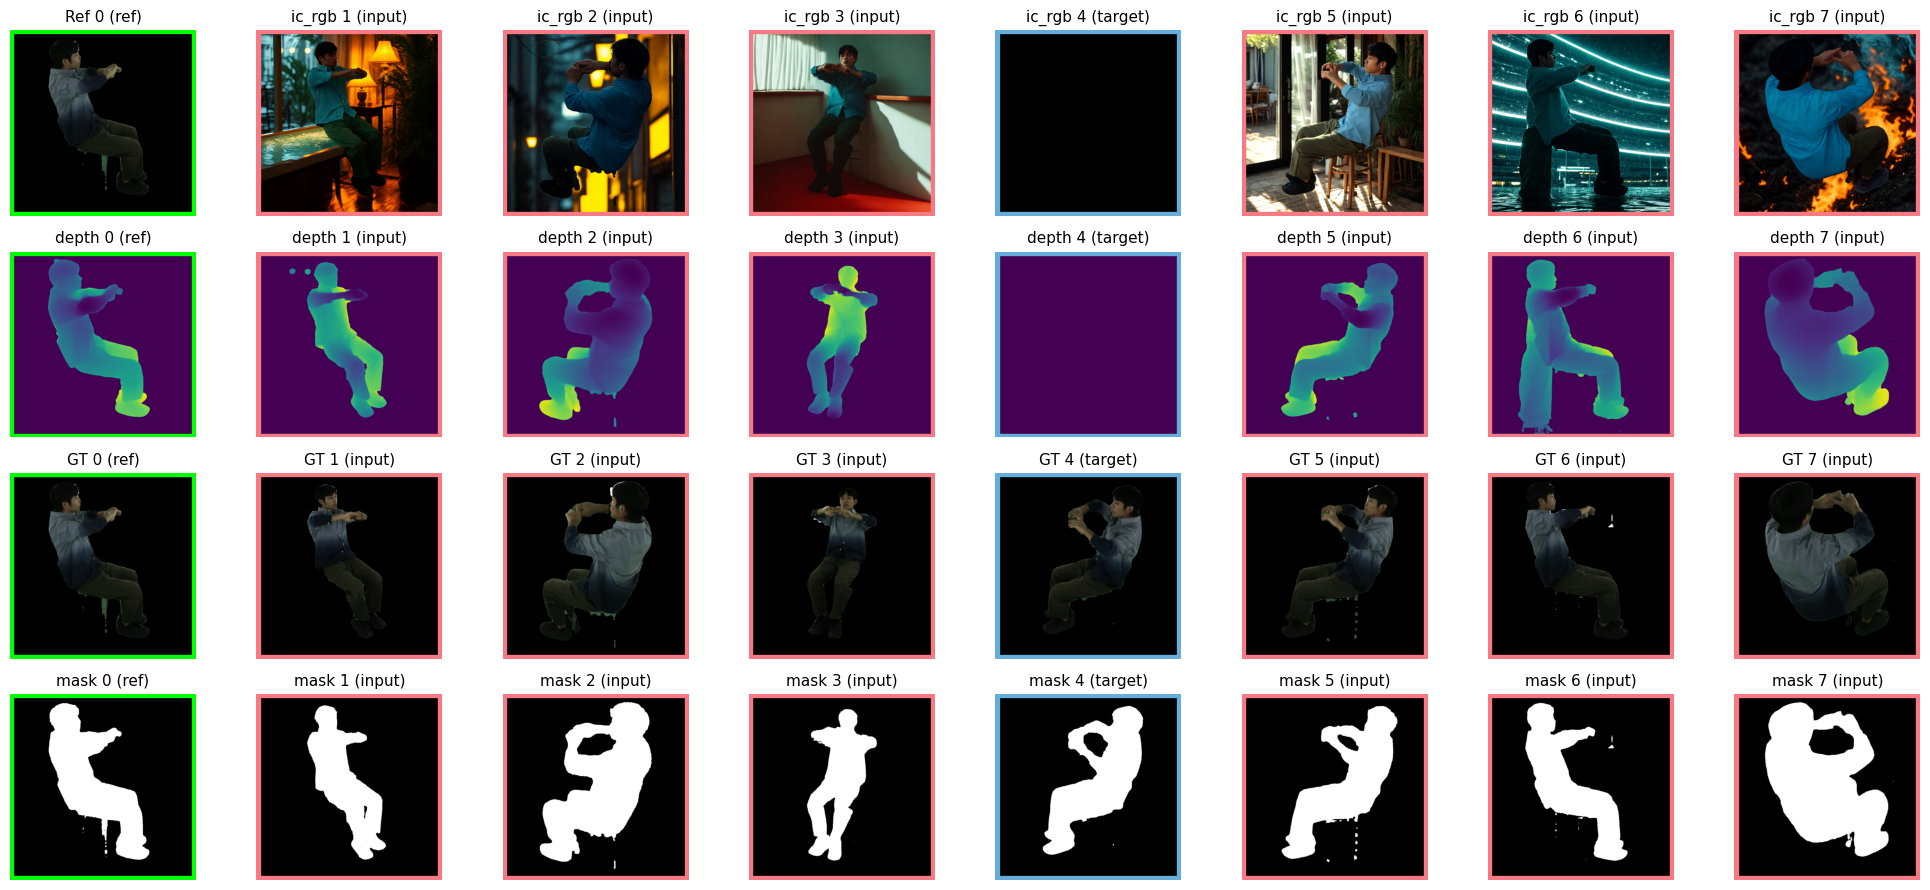

ic_rgb shape: torch.Size([1, 8, 3, 576, 576]), sapiens_conditioning[depth] shape: torch.Size([1, 8, 1, 576, 576]), frames shape: torch.Size([1, 8, 3, 576, 576]), frames_masks shape: torch.Size([1, 8, 1, 576, 576])


In [24]:
# Visualize batch data in the style of main.py's ImageLogger (clear, normalized, grid, robust handling)
import matplotlib.pyplot as plt
import numpy as np
import torch

def tensor_to_rgb(tensor):
    """
    Converts a tensor to [H, W, 3] ndarray with values in [0, 1].
    Handles (3, H, W) or (H, W, 3). Clips and scales from [-1, 1] if needed.
    """
    if tensor.ndim == 3 and tensor.shape[0] == 3:
        img = tensor.permute(1, 2, 0).detach().cpu().float()
    elif tensor.ndim == 3 and tensor.shape[-1] == 3:
        img = tensor.detach().cpu().float()
    else:
        raise ValueError(f"Unexpected shape for RGB image tensor: {tensor.shape}")
    img = img.clamp(-1, 1)
    img = (img + 1) * 0.5
    img = img.clamp(0, 1)
    return img.numpy()

def tensor_to_gray(tensor):
    """
    Converts a tensor of shape (1, H, W) or (H, W) to [H, W] ndarray [0,1].
    """
    if tensor.ndim == 3 and tensor.shape[0] == 1:
        img = tensor[0].detach().cpu().float()
    elif tensor.ndim == 2:
        img = tensor.detach().cpu().float()
    else:
        raise ValueError(f"Unexpected shape for mask tensor: {tensor.shape}")
    img = img.clamp(0, 1)
    return img.numpy()

def vis_grid(images, titles=None, row_title=None, cmap=None):
    """
    Helper to visualize a row of images, like in ImageLogger.
    images: list of np.ndarrays or tensors
    titles: optional list of titles
    row_title: optional row title (displayed at the left)
    cmap: optional matplotlib colormap for all images in this row
    """
    n = len(images)
    for i, img in enumerate(images):
        ax = plt.gca()
        if cmap is not None:
            ax.imshow(img, cmap=cmap)
        else:
            ax.imshow(img)
        if titles is not None:
            ax.set_title(titles[i], fontsize=12)
        else:
            ax.set_title(str(i), fontsize=12)
        ax.axis('off')
        if i < n-1:
            plt.gca().set_xticks([])
    if row_title is not None:
        plt.ylabel(row_title, fontsize=16, rotation=0, labelpad=60, va='center')

# Define ImageLogger color scheme
BORDER_RED = (247/255, 121/255, 132/255)    # inputs
BORDER_BLUE = (101/255, 174/255, 219/255)   # targets
BORDER_GREEN = (0/255, 255/255, 0/255)      # reference

print("mask:", batch["mask"])
print("ref_mask:", batch["ref_mask"])

# Prepare image batches
ic_rgb = batch["ic_rgb"].squeeze(0).detach().cpu()       # (N, 3, H, W)
frames = batch["frames"].squeeze(0).detach().cpu()       # (N, 3, H, W)
frames_masks = batch["frames_masks"].squeeze(0).detach().cpu()  # (N, 1, H, W) or (N, 3, H, W) etc.
depths = batch["sapiens_conditioning"]["depth"].squeeze(0).detach().cpu() # (N, 3, H, W) or (N, 1, H, W)

N = ic_rgb.shape[0]
assert depths.shape[0] == N and frames_masks.shape[0] == N

# For each "slot"/frame, visualize all tracks as a row of images with normalized display.
fig, axs = plt.subplots(4, N, figsize=(2.5*N, 9))

# Determine border colors for each frame based on masks
ref_mask = batch["ref_mask"].squeeze(0) if batch["ref_mask"].dim() > 1 else batch["ref_mask"]
input_mask = batch["mask"].squeeze(0) if batch["mask"].dim() > 1 else batch["mask"]

for i in range(N):
    # Determine border color using ImageLogger logic
    is_ref = ref_mask[i].item() if ref_mask.dim() == 1 else ref_mask[0, i].item()
    is_input = input_mask[i].item() if input_mask.dim() == 1 else input_mask[0, i].item()
    
    # Priority: reference (green) > input (red) > target (blue)
    if is_ref:
        border_color = BORDER_GREEN
        title_suffix = " (ref)"
    elif is_input:
        border_color = BORDER_RED
        title_suffix = " (input)"
    else:
        border_color = BORDER_BLUE
        title_suffix = " (target)"
    
    # Row 0: ic_rgb or reference frames (following ImageLogger: highlight ref frames)
    if is_ref:
        img = tensor_to_rgb(frames[i])
        title = f"Ref {i}{title_suffix}"
    else:
        img = tensor_to_rgb(ic_rgb[i])
        title = f"ic_rgb {i}{title_suffix}"
    
    axs[0, i].imshow(img)
    # Add border matching ImageLogger style (thicker border for emphasis)
    axs[0, i].add_patch(plt.Rectangle((0, 0), img.shape[1], img.shape[0], 
                                       fill=False, edgecolor=border_color, linewidth=6))
    axs[0, i].set_title(title, fontsize=11)
    axs[0, i].axis('off')
    
    # Row 1: sapiens_conditioning['depth']
    # Handle both 1-channel and 3-channel depth maps
    depth = depths[i]
    if depth.ndim == 3 and depth.shape[0] == 1:
        # Single channel depth - normalize from [-1, 1] to [0, 1] if needed
        depth_tensor = depth[0].detach().cpu().float()
        # Check if values are in [-1, 1] range and normalize if needed
        if depth_tensor.min() < 0:
            depth_tensor = depth_tensor.clamp(-1, 1)
            depth_tensor = (depth_tensor + 1) * 0.5  # [-1, 1] -> [0, 1]
        else:
            depth_tensor = depth_tensor.clamp(0, 1)
        depth_img = depth_tensor.numpy()
        axs[1, i].imshow(depth_img, cmap="viridis")  # Use colormap for better depth visualization
    elif depth.ndim == 3 and depth.shape[0] == 3:
        # RGB depth - use RGB visualization
        depth_img = tensor_to_rgb(depth)
        axs[1, i].imshow(depth_img)
    elif depth.ndim == 2:
        # 2D depth map - normalize if needed
        depth_tensor = depth.detach().cpu().float()
        if depth_tensor.min() < 0:
            depth_tensor = depth_tensor.clamp(-1, 1)
            depth_tensor = (depth_tensor + 1) * 0.5  # [-1, 1] -> [0, 1]
        else:
            depth_tensor = depth_tensor.clamp(0, 1)
        depth_img = depth_tensor.numpy()
        axs[1, i].imshow(depth_img, cmap="viridis")
    else:
        # Fallback: try to extract first channel
        if depth.ndim == 3:
            depth_tensor = depth[0].detach().cpu().float()
        else:
            depth_tensor = depth.unsqueeze(0)[0].detach().cpu().float()
        if depth_tensor.min() < 0:
            depth_tensor = depth_tensor.clamp(-1, 1)
            depth_tensor = (depth_tensor + 1) * 0.5
        else:
            depth_tensor = depth_tensor.clamp(0, 1)
        depth_img = depth_tensor.numpy()
        axs[1, i].imshow(depth_img, cmap="viridis")
    
    # Add colored border to depth visualization
    axs[1, i].add_patch(plt.Rectangle((0, 0), depth_img.shape[1] if depth_img.ndim == 2 else depth_img.shape[0], 
                                       depth_img.shape[0] if depth_img.ndim == 2 else depth_img.shape[1], 
                                       fill=False, edgecolor=border_color, linewidth=6))
    axs[1, i].set_title(f"depth {i}{title_suffix}", fontsize=11)
    axs[1, i].axis('off')
    
    # Row 2: original GT frame
    frame_img = tensor_to_rgb(frames[i])
    axs[2, i].imshow(frame_img)
    axs[2, i].add_patch(plt.Rectangle((0, 0), frame_img.shape[1], frame_img.shape[0], 
                                       fill=False, edgecolor=border_color, linewidth=6))
    axs[2, i].set_title(f"GT {i}{title_suffix}", fontsize=11)
    axs[2, i].axis('off')
    
    # Row 3: input mask (show gray if 1 channel, else RGB; grayscale if ambiguous shape)
    mask = frames_masks[i]
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask_img = tensor_to_gray(mask)
        axs[3, i].imshow(mask_img, cmap="gray")
        mask_h, mask_w = mask_img.shape
    elif mask.ndim == 3 and mask.shape[0] == 3:
        mask_img = tensor_to_rgb(mask)
        axs[3, i].imshow(mask_img)
        mask_h, mask_w = mask_img.shape[0], mask_img.shape[1]
    elif mask.ndim == 2:
        mask_img = mask.cpu().float().clamp(0, 1).numpy()
        axs[3, i].imshow(mask_img, cmap="gray")
        mask_h, mask_w = mask_img.shape
    else:
        # fallback
        mask_img = mask[0].cpu().float().clamp(0, 1).numpy()
        axs[3, i].imshow(mask_img, cmap="gray")
        mask_h, mask_w = mask_img.shape
    
    axs[3, i].add_patch(plt.Rectangle((0, 0), mask_w, mask_h, 
                                       fill=False, edgecolor=border_color, linewidth=6))
    axs[3, i].set_title(f"mask {i}{title_suffix}", fontsize=11)
    axs[3, i].axis('off')

# Label each row on the left (like in main.py grids: inputs, conditions, etc.)
axs[0, 0].set_ylabel("Reference/\nic_rgb", fontsize=13, rotation=0, labelpad=40, va='center')
axs[1, 0].set_ylabel("Depth", fontsize=13, rotation=0, labelpad=40, va='center')
axs[2, 0].set_ylabel("GT", fontsize=13, rotation=0, labelpad=40, va='center')
axs[3, 0].set_ylabel("Frame Mask", fontsize=13, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()

print(f"ic_rgb shape: {batch['ic_rgb'].shape}, sapiens_conditioning[depth] shape: {batch['sapiens_conditioning']['depth'].shape}, frames shape: {batch['frames'].shape}, frames_masks shape: {batch['frames_masks'].shape}")

tensor([[ True, False, False, False, False, False, False, False]],
       device='cuda:0')
tensor([[ True,  True,  True,  True, False,  True,  True,  True]],
       device='cuda:0')


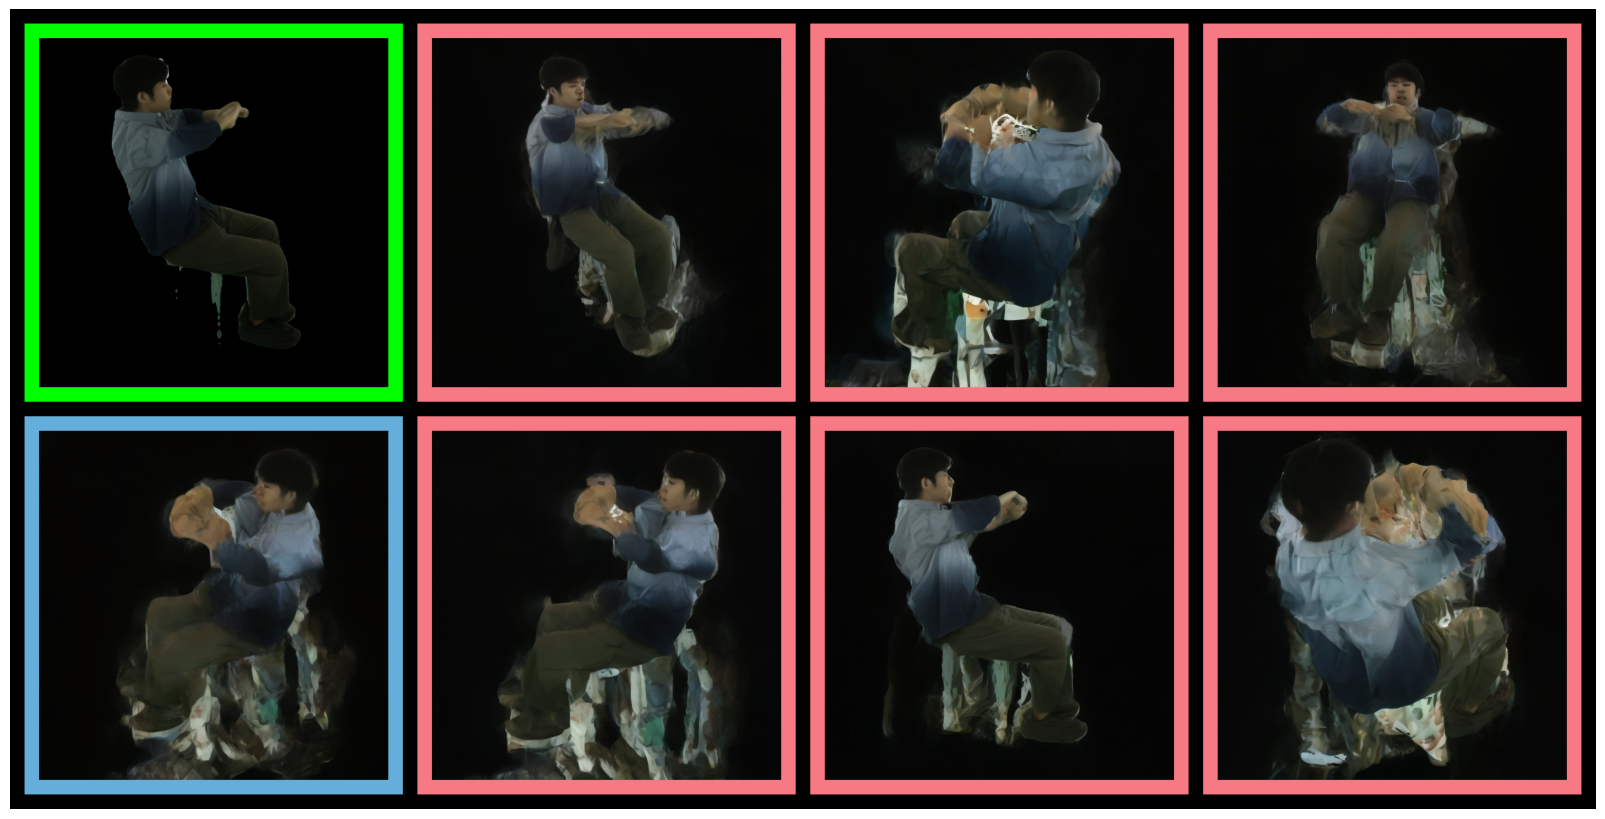

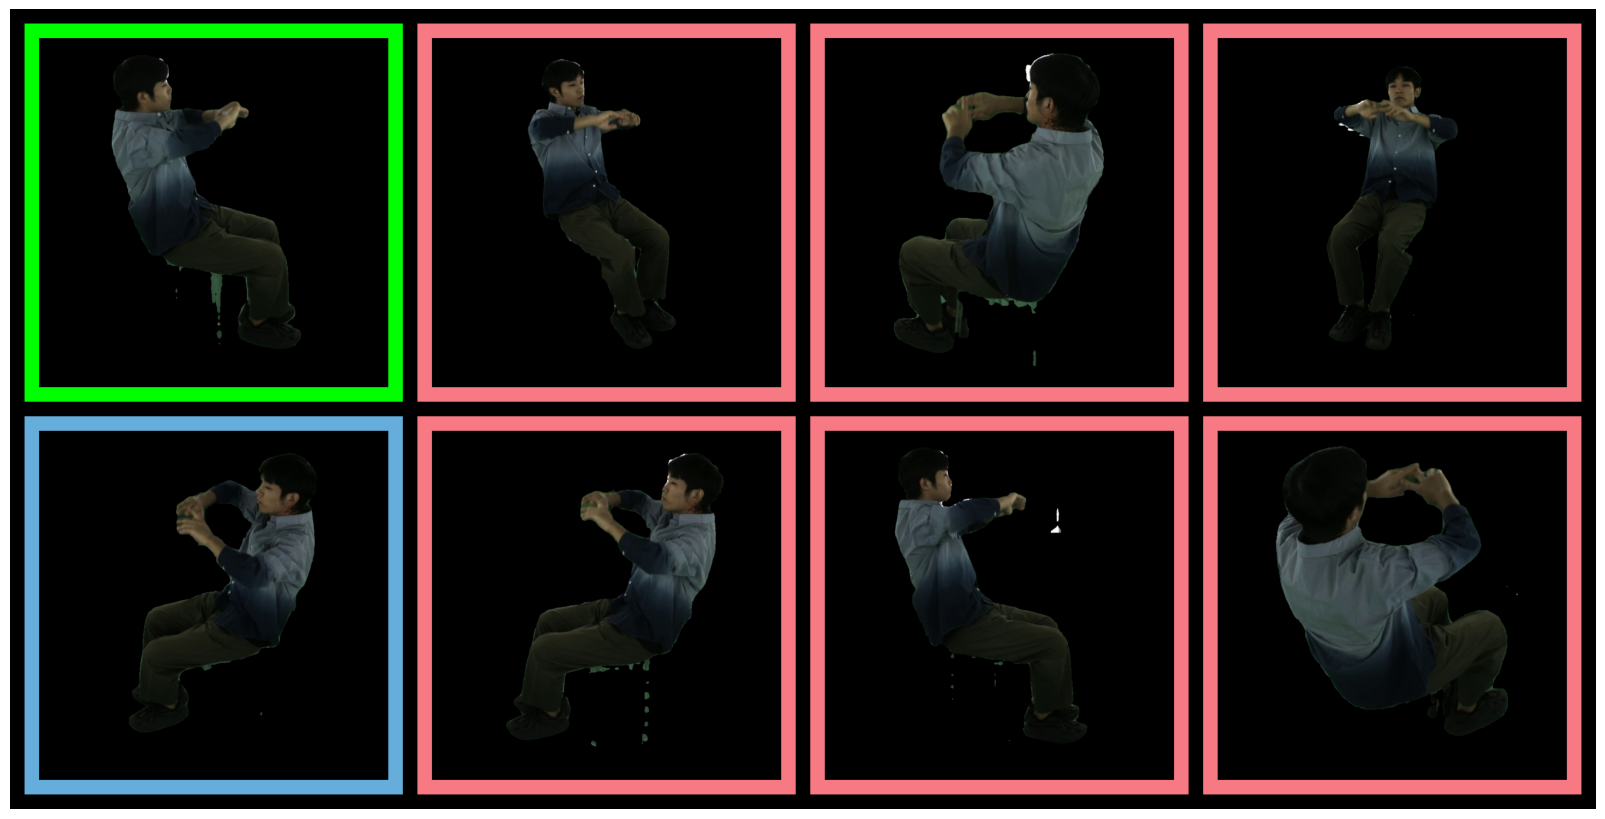

In [23]:
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch

def save_image_batch(batch, samples, output_dir="output_samples"):
    # saves resulting images to a directory
    # reference image (mask) will be called "ref.png"
    # input images will be called "input_<index>.png"
    # output images will be called "target_<index>.png"
    os.makedirs(os.path.join(output_dir, batch["subject_id"][0]), exist_ok=True)
    
    import torchvision.utils as vutils
    
    # Save reference mask
    ref_mask = batch["ref_mask"].squeeze(0)  # Remove batch dimension
    samples = samples.squeeze(0) if samples.dim() == 4 else samples  # Handle batch dimension if present
    for i in range(samples.shape[0]):
        name = f"{i}_target.png"
        if ref_mask[i] == 1:
            name = f"{i}_ref.png"

        vutils.save_image(samples[i], os.path.join(output_dir, batch["subject_id"][0], name))
    torch.save(samples, os.path.join(output_dir, batch["subject_id"][0], "batch.pt"))
    torch.save(samples, os.path.join(output_dir, batch["subject_id"][0], "samples.pt"))

decoded_samples = normalize_tensor(engine.decode_first_stage(samples)).to("cpu")
print(batch["ref_mask"])
print(batch["mask"])
_ = show_tensor_batch(decoded_samples, ref_mask=(batch["ref_mask"].to("cpu")).squeeze(0), input_mask=batch["mask"].to("cpu").squeeze(0))
_ = show_tensor_batch(normalize_tensor(batch["frames"].squeeze(0)), ref_mask=(batch["ref_mask"].to("cpu")).squeeze(0), input_mask=batch["mask"].to("cpu").squeeze(0))
save_image_batch(batch, decoded_samples)